In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt

In [2]:
df = pd.read_csv('/Users/dmitrystarukhin/final_diploma_mipt_sumgf/moscow/moscow_data/final_datasets/dataset_moscow.csv')

In [3]:
df.describe()

,latitude,longitude,beauty_amenities,bike_amenities,car_amenities,children_amenity,food_amenities,health_amenity,home_amenities,infrastructure_amenities,...,social_amenities,study_amenity,water_amenities,work_amenity,parking_area,traffic_count,highway,voltage,сharger_number,distance_to_center
count,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,...,2789.000000,2789.000000,2789.000000,2789.000000,2.789000e+03,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000
mean,55.635510,37.446324,1.956974,1.324489,3.020437,1.378272,5.795626,3.281463,0.750090,3.073503,...,5.735389,0.403370,0.058444,5.556472,1.608540e+05,23432.645305,11.175332,69179.204016,1.912155,25.069766
std,0.181757,0.237395,4.665836,3.649421,4.774237,2.691978,13.310435,6.398923,2.579636,7.444147,...,10.660550,1.053996,0.593325,12.293756,2.653513e+05,0.000000,15.787702,110687.959364,4.565932,16.938338
min,55.165475,36.805188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,23432.645305,0.000000,0.000000,0.000000,0.384918
25%,55.508330,37.290779,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,23432.645305,0.000000,0.000000,0.000000,12.430693
50%,55.651170,37.460681,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,5.686268e+04,23432.645305,4.000000,0.000000,0.000000,18.751609
75%,55.774476,37.619592,2.000000,1.000000,4.000000,2.000000,6.000000,4.000000,1.000000,4.000000,...,8.000000,0.000000,0.000000,6.000000,2.234801e+05,23432.645305,17.000000,110000.000000,2.000000,35.980112
max,56.019612,37.962189,53.000000,57.000000,42.000000,28.000000,168.000000,58.000000,65.000000,145.000000,...,200.000000,18.000000,24.000000,132.000000,4.174979e+06,23432.645305,101.000000,500000.000000,61.000000,74.302730


In [4]:
df.columns

Index(['h3_index', 'latitude', 'longitude', 'beauty_amenities',
       'bike_amenities', 'car_amenities', 'children_amenity', 'food_amenities',
       'health_amenity', 'home_amenities', 'infrastructure_amenities',
       'leisure_amenities', 'needs_amenities', 'other_amenities',
       'pet_amenity', 'public_transport', 'shops_amenities',
       'social_amenities', 'study_amenity', 'water_amenities', 'work_amenity',
       'parking_area', 'traffic_count', 'highway', 'voltage', 'сharger_number',
       'distance_to_center'],
      dtype='object')

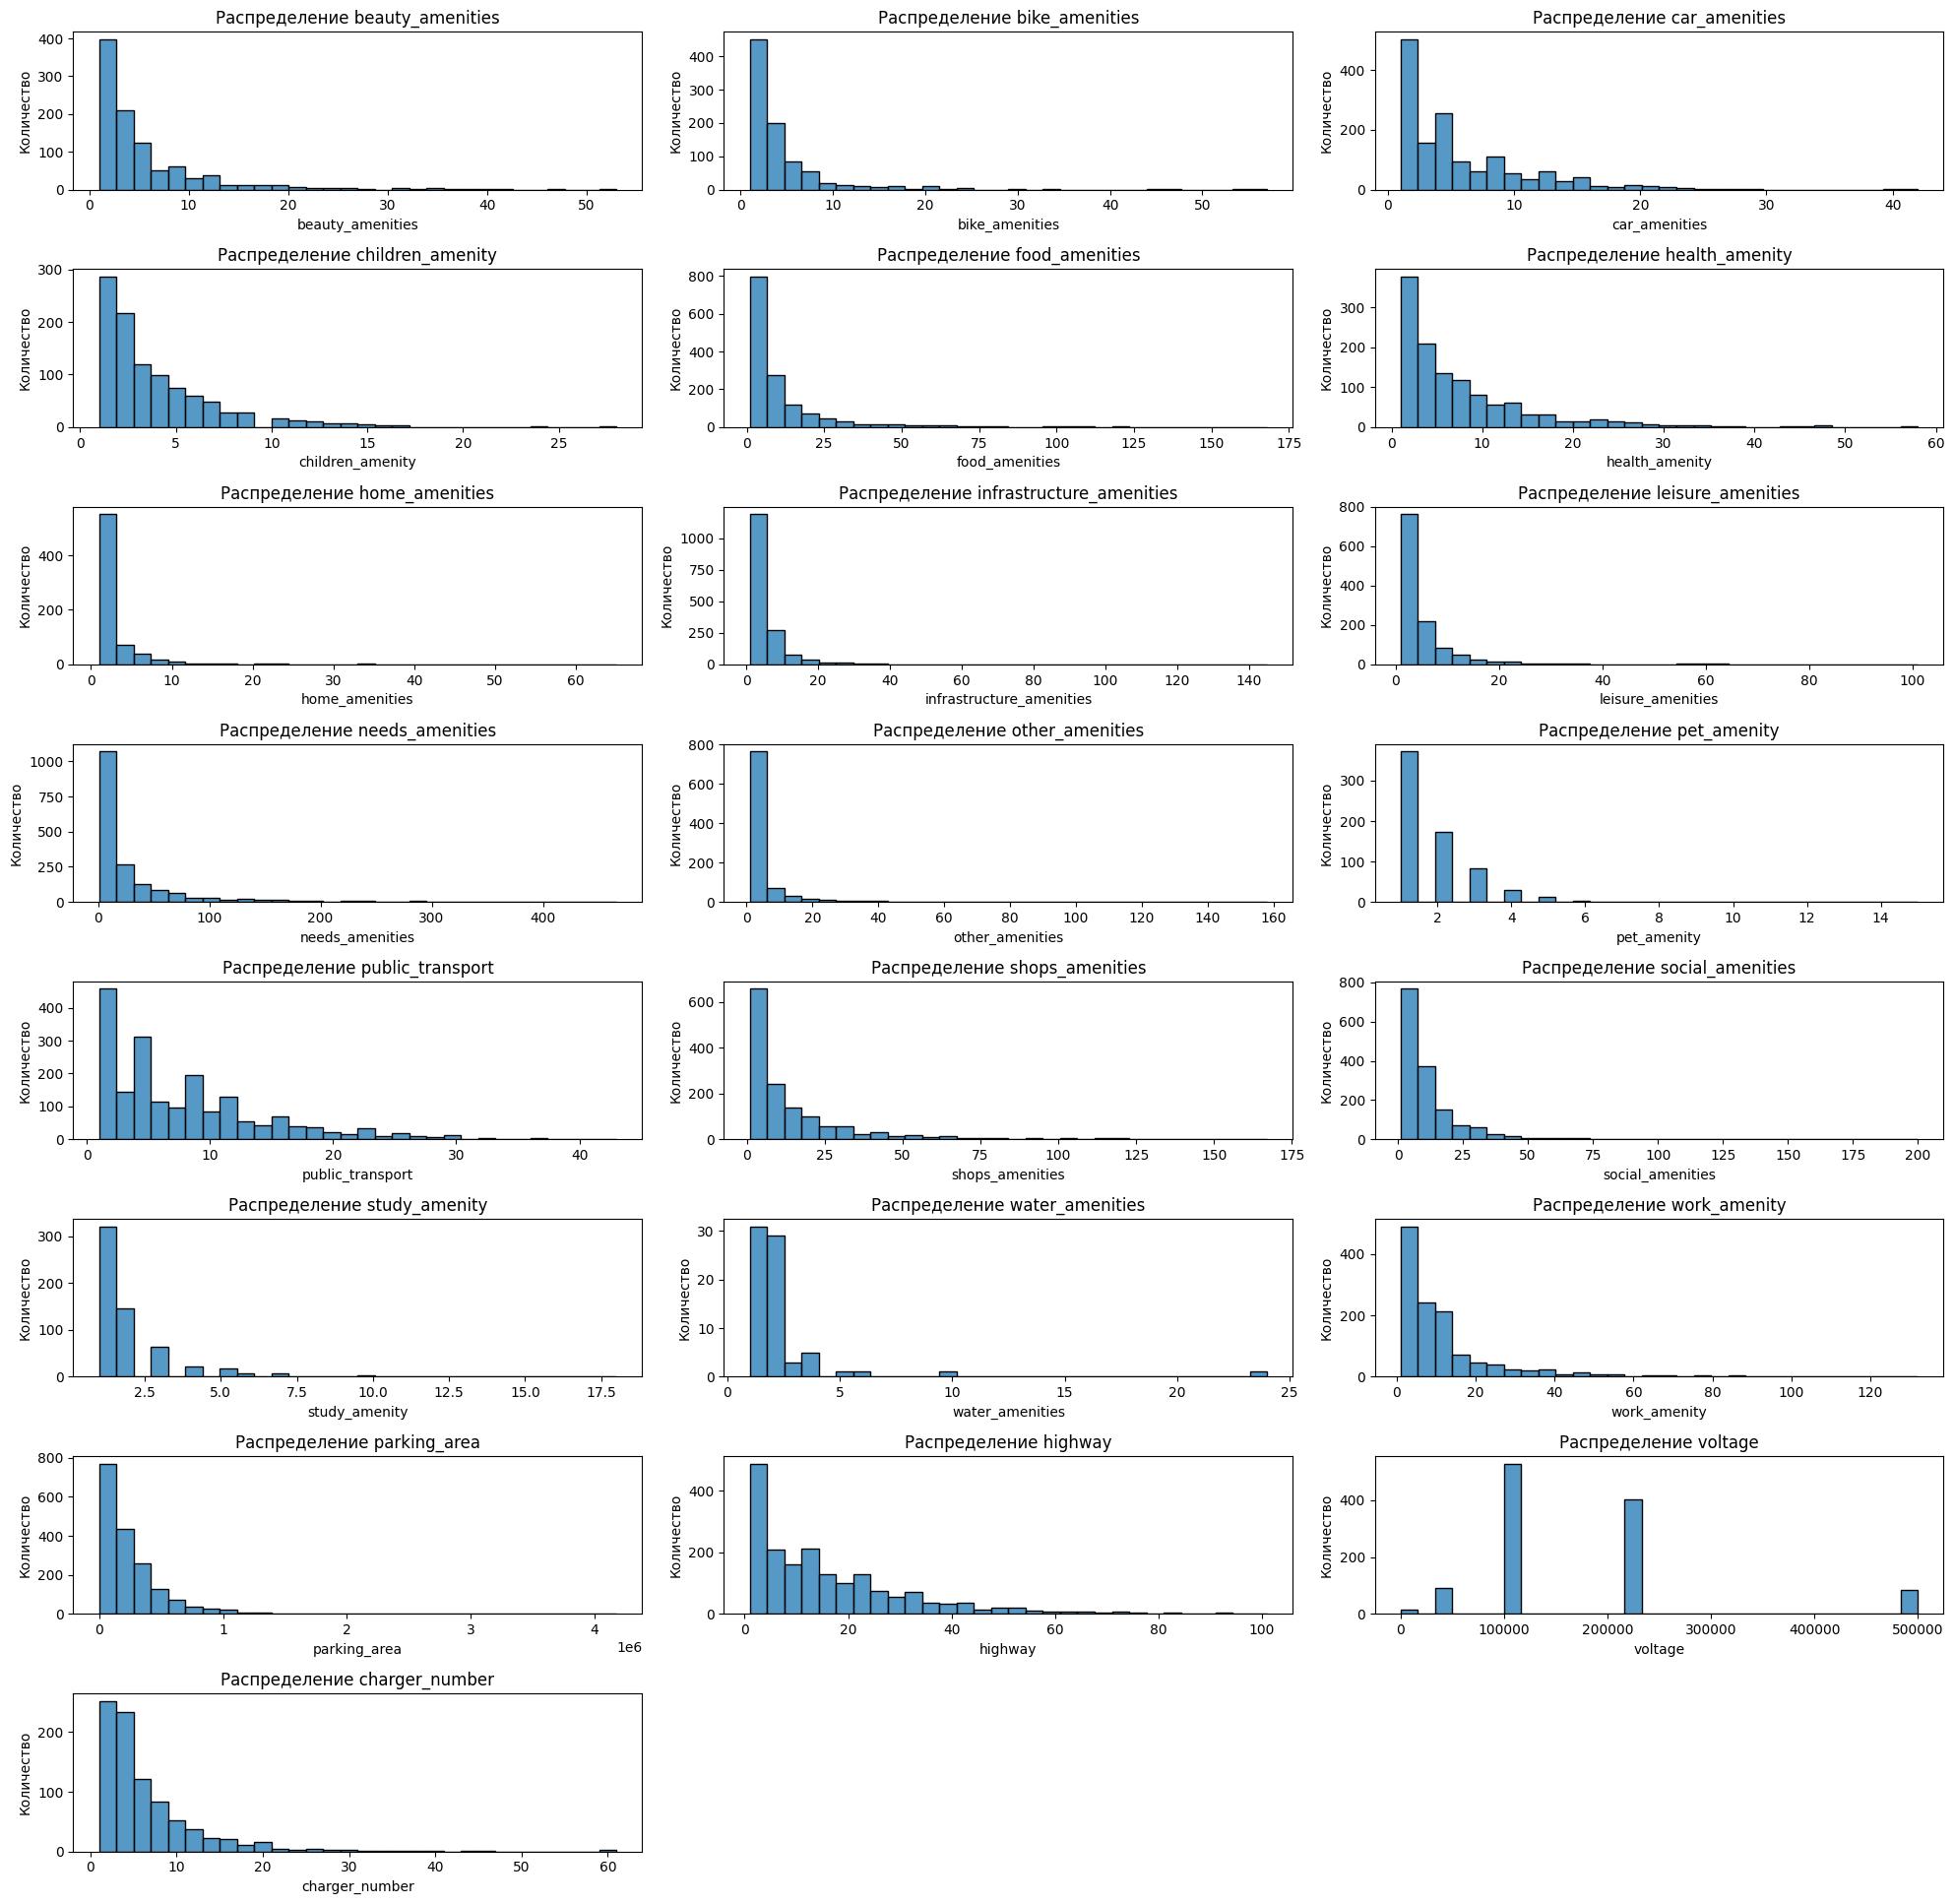

In [12]:
# распредление данных без учета 0 и nothing
columns_to_plot = [
    'beauty_amenities',
       'bike_amenities', 'car_amenities', 'children_amenity', 'food_amenities',
       'health_amenity', 'home_amenities', 'infrastructure_amenities',
       'leisure_amenities', 'needs_amenities', 'other_amenities',
       'pet_amenity', 'public_transport', 'shops_amenities',
       'social_amenities', 'study_amenity', 'water_amenities', 'work_amenity',
       'parking_area', 'highway', 'voltage', 'сharger_number'
]


plt.figure(figsize=(20, 60))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(25, 3, i)
    sns.histplot(df[df[col] != 0][col], bins=30)  
    plt.title(f"Распределение {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")

plt.tight_layout()
plt.show()

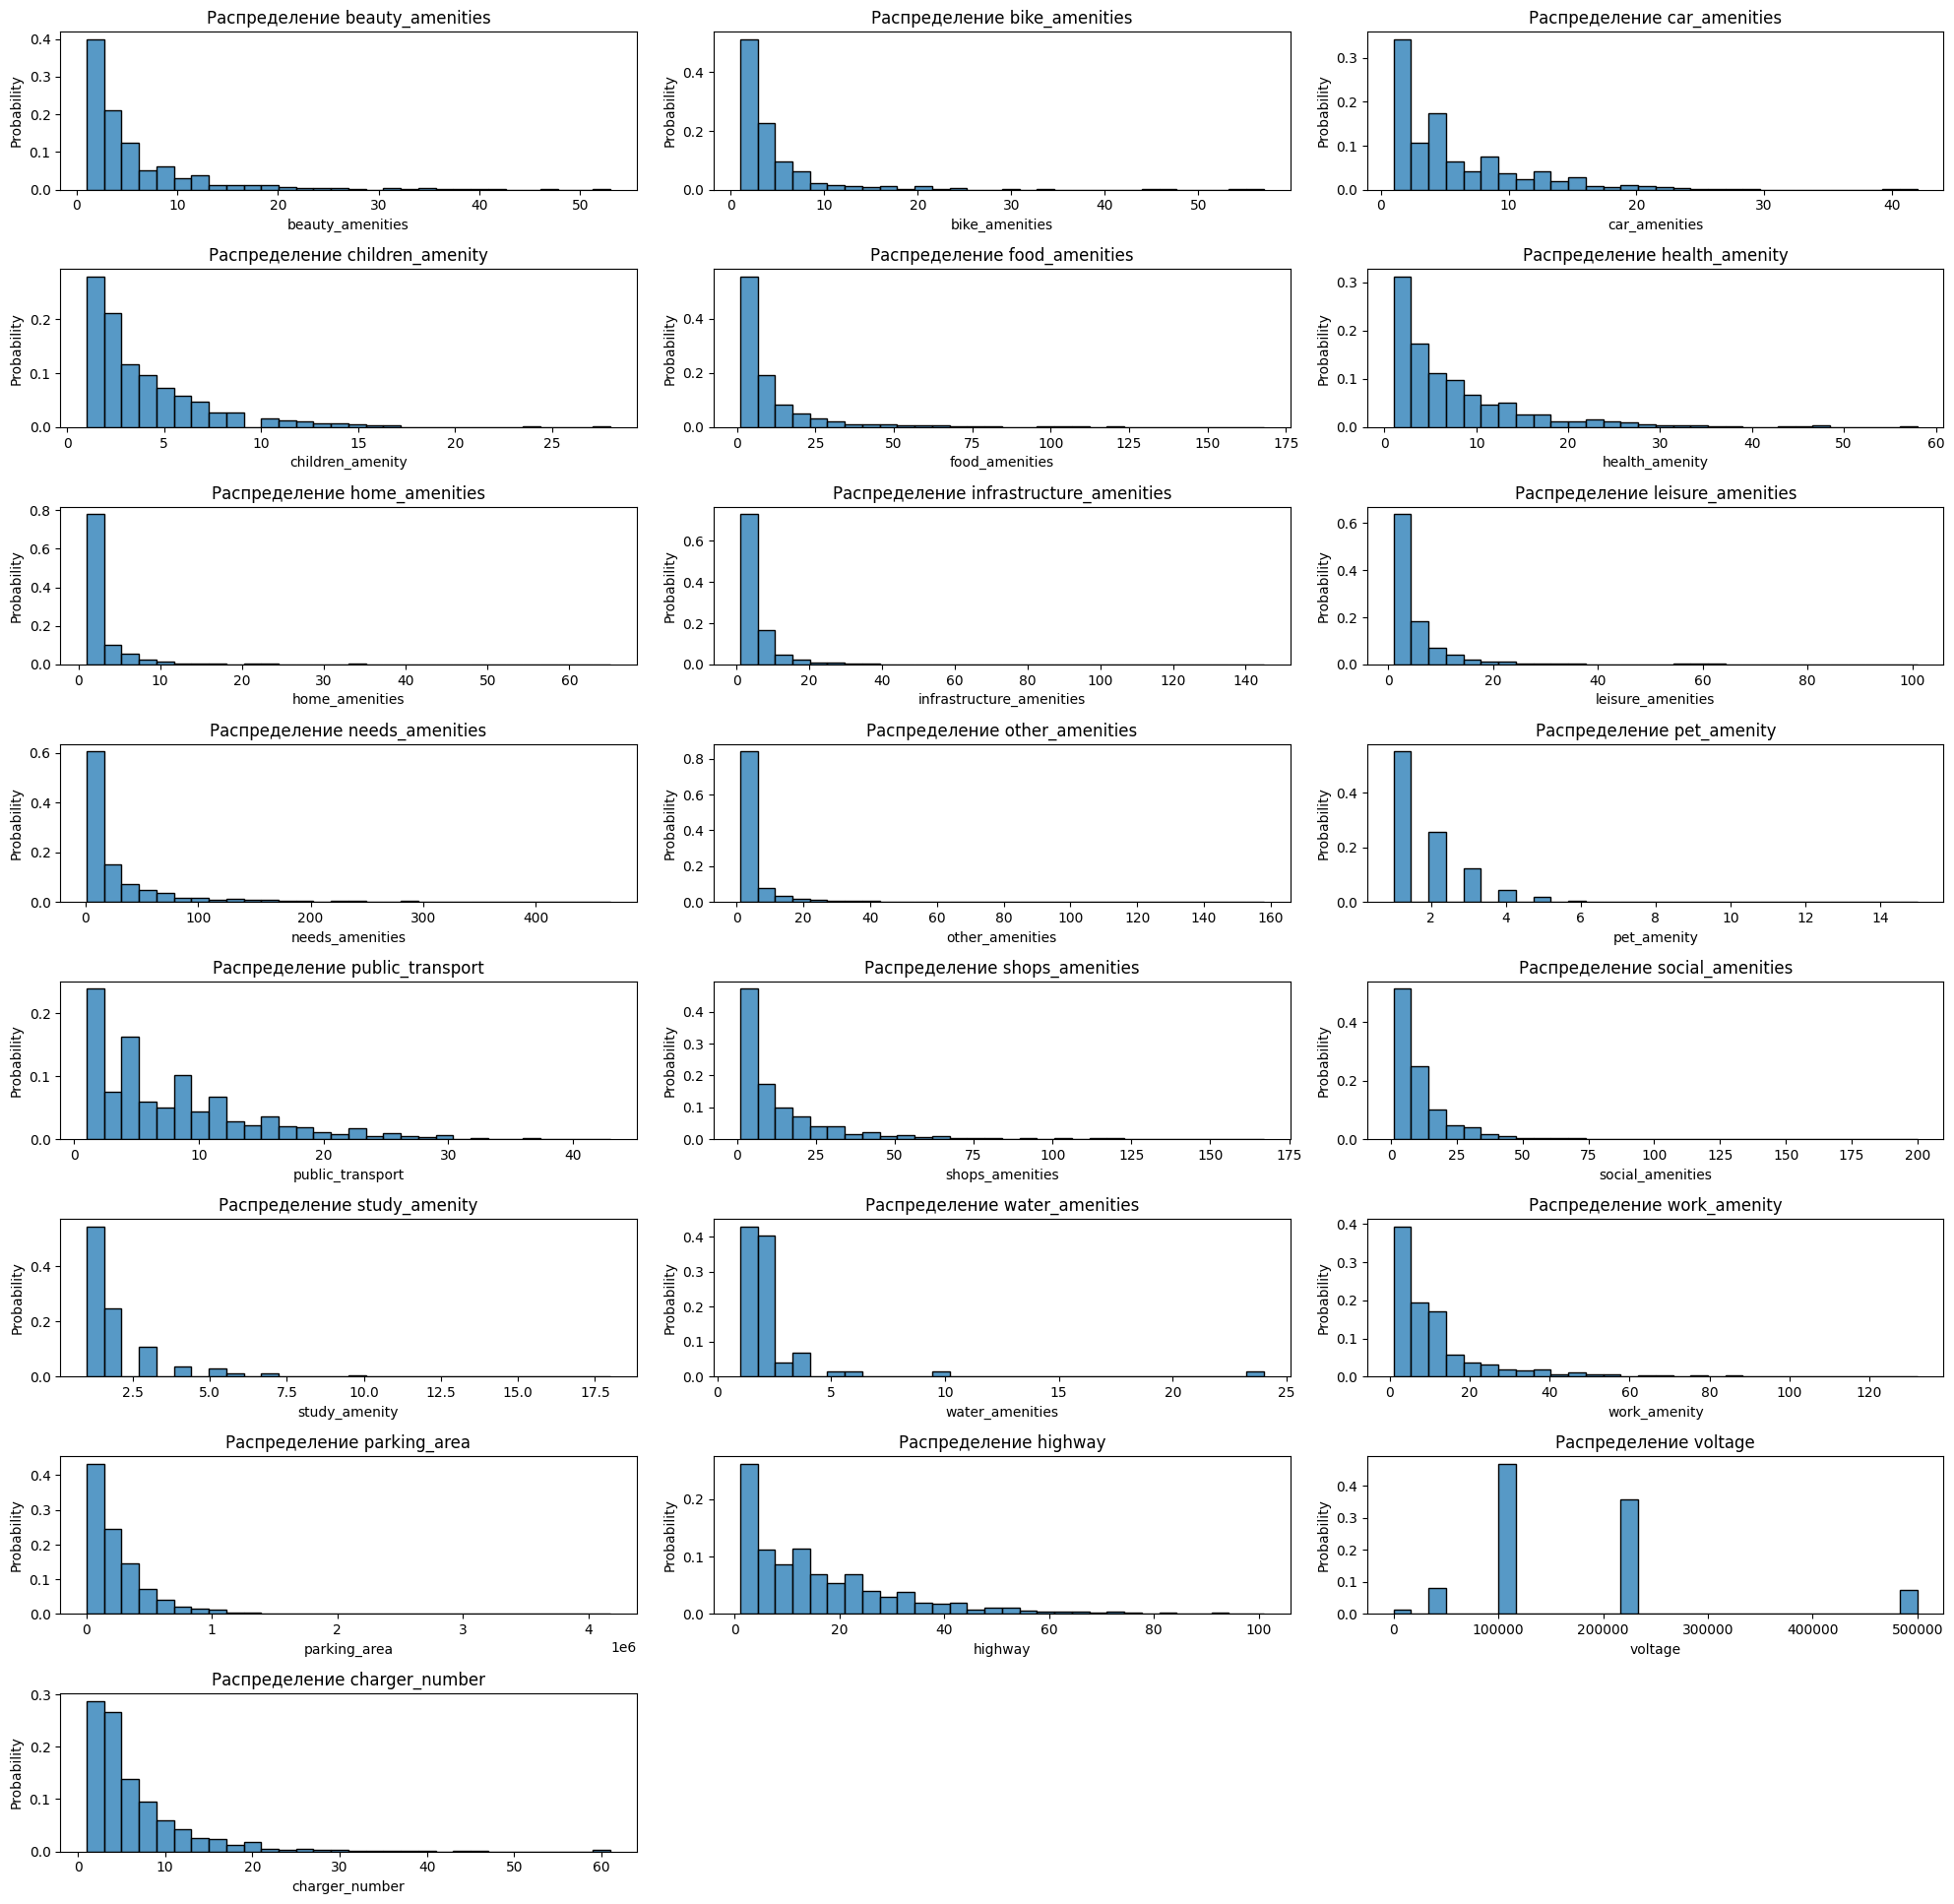

In [13]:
plt.figure(figsize=(20, 60))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(25, 3, i)
    
    sns.histplot(df[df[col] != 0][col], bins=30, stat="probability")  
    
    plt.title(f"Распределение {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

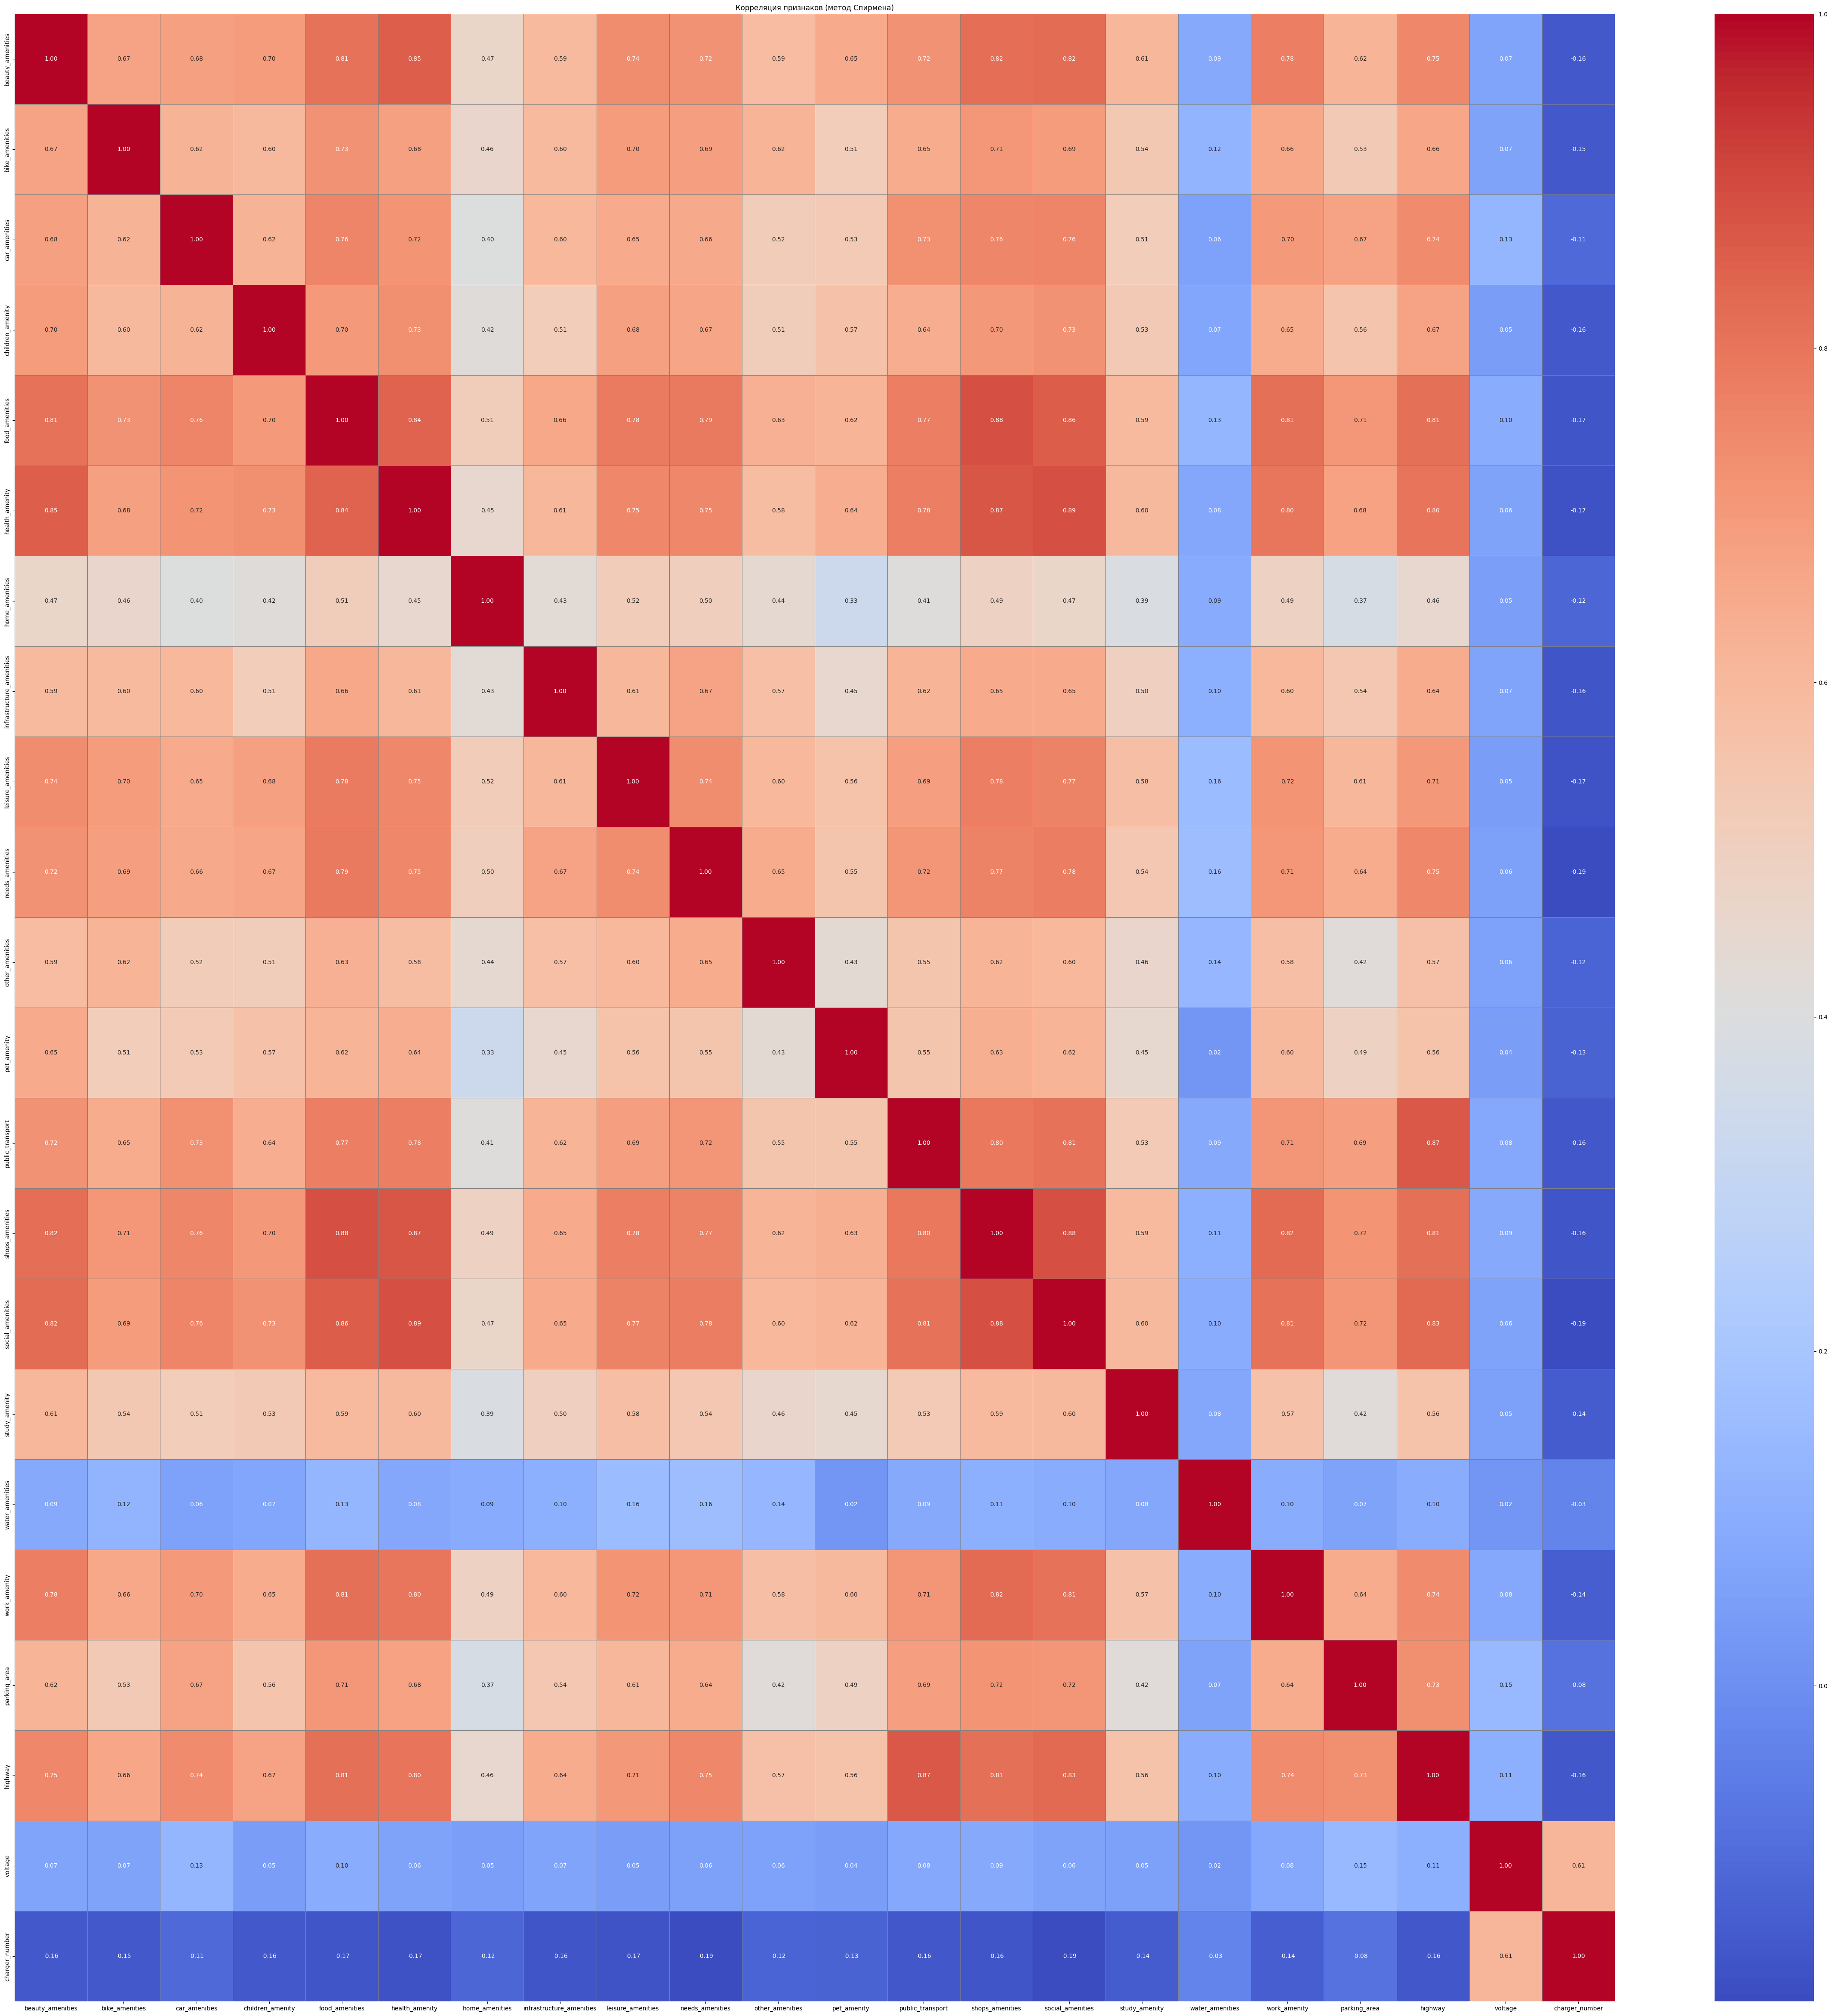

In [14]:
corr_matrix = df[columns_to_plot].corr(method='spearman', numeric_only=True)

plt.figure(figsize=(60, 60))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, linecolor='gray')

plt.title("Корреляция признаков (метод Спирмена)")
plt.show()

In [15]:
num_classes = 1000

df["distance_class"] = pd.qcut(df["distance_to_center"], num_classes, labels=False, duplicates="drop")


aggregated_data = {}

for col in columns_to_plot:
    if col != 'usage_type':
        filtered_df = df[df[col] > 0]
        
        aggregated = filtered_df.groupby("distance_class")[col].agg(["mean", "median"])
        
        aggregated_data[col] = aggregated

aggregated_df = pd.concat(aggregated_data, axis=1)

aggregated_df.head()

beauty_amenities        bike_amenities        car_amenities  \
                           mean median           mean median          mean   
distance_class                                                               
0                      7.333333    8.0      10.000000   10.0     12.000000   
1                     13.666667   12.0      15.000000   15.0     12.666667   
2                     29.333333   28.0      23.000000   24.0     19.666667   
3                     31.666667   32.0      43.666667   47.0     13.000000   
4                     33.500000   33.5      40.000000   40.0     30.500000   

                      children_amenity        food_amenities         ...  \
               median             mean median           mean median  ...   
distance_class                                                       ...   
0                13.0         2.500000    2.5      57.000000   39.0  ...   
1                14.0         5.000000    5.0      75.666667   64.0  ...   
2                18.0         5.333333    6.0      69.666667   67.0  ...   
3                12.0         2.333333    2.0     100.666667  106.0  ...   
4                30.5         3.000000    3.0      74.000000   74.0  ...   

               work_amenity          parking_area                   highway  \
                       mean median           mean         median       mean   
distance_class                                                                
0                 18.000000   20.0  355992.414022  278095.723122  53.666667   
1                 41.333333   44.0  279852.022058  272273.006962  59.000000   
2                 49.333333   48.0  102746.493728  114360.663376  86.000000   
3                 76.666667   66.0   92644.951833   69547.022561  77.666667   
4                 42.000000   42.0  127336.804324  127336.804324  77.000000   

                        voltage           сharger_number         
               median      mean    median           mean median  
distance_class                                                   
0                46.0  110000.0  110000.0            NaN    NaN  
1                60.0  110000.0  110000.0            NaN    NaN  
2                86.0  110000.0  110000.0            NaN    NaN  
3                83.0       NaN       NaN            NaN    NaN  
4                77.0  110000.0  110000.0            NaN    NaN  

[5 rows x 44 columns]

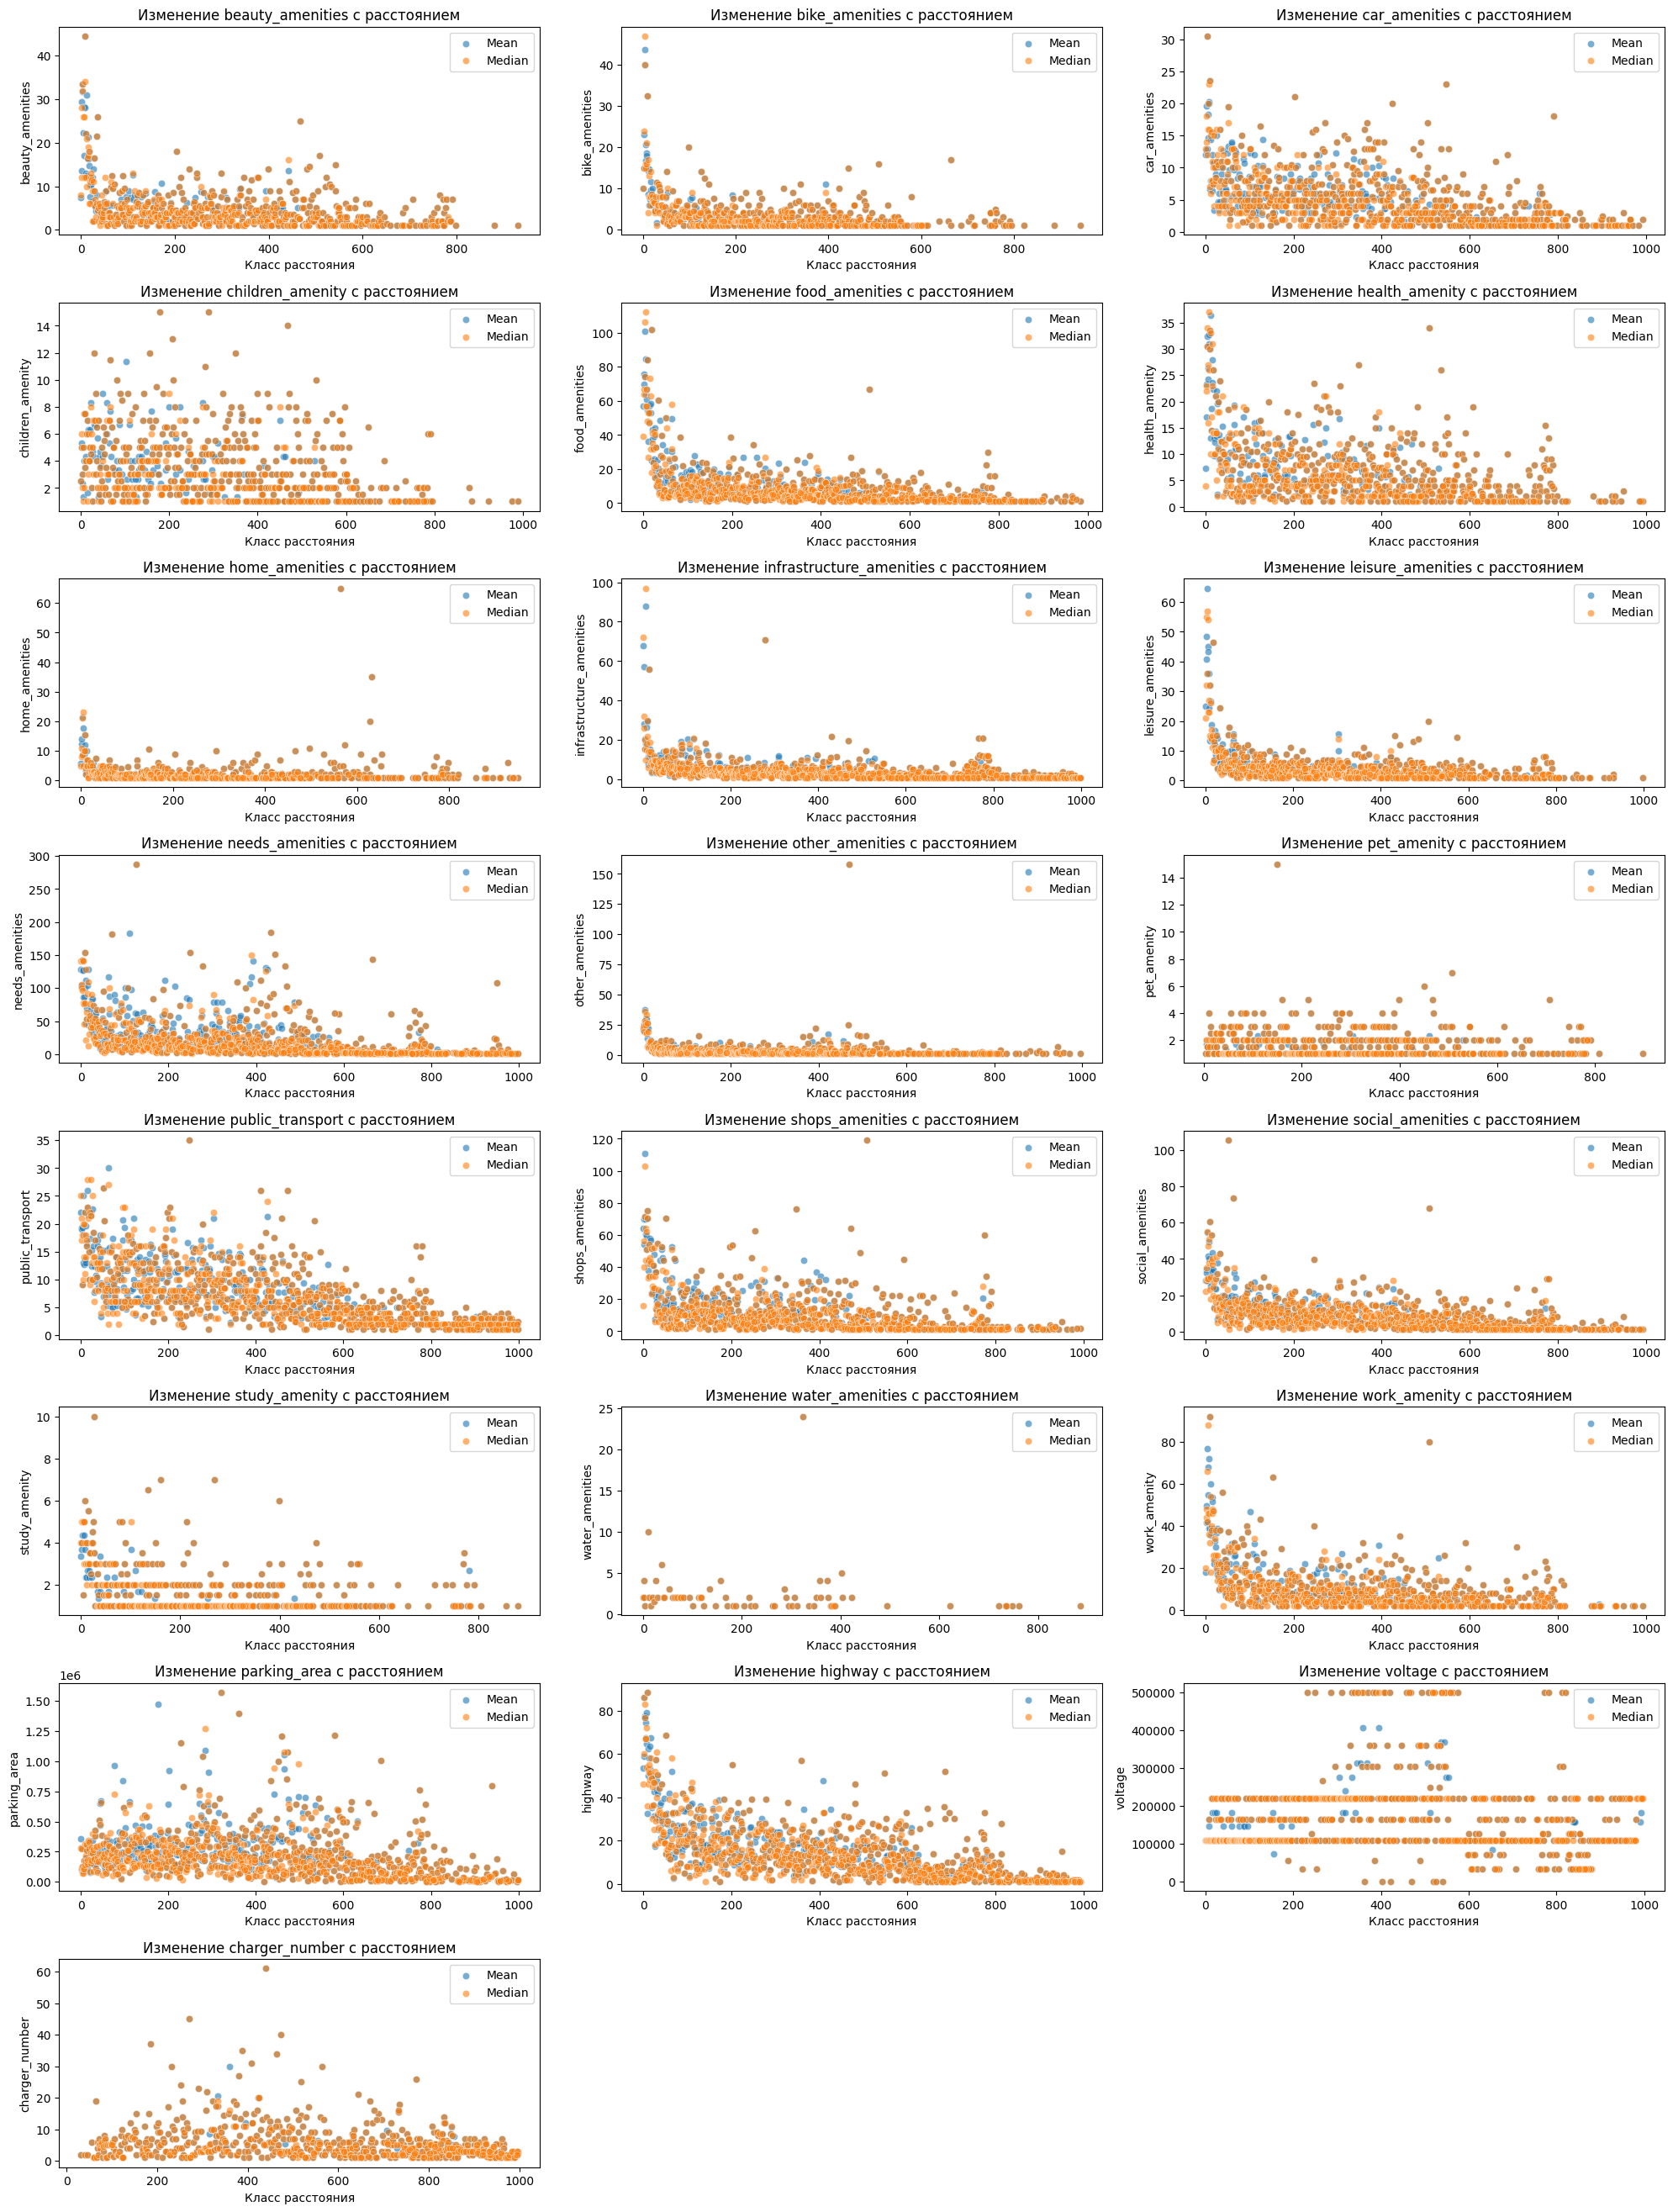

In [16]:
plt.figure(figsize=(20, 200))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(61, 3, i)
    
    data = aggregated_df[col]

    sns.scatterplot(x=aggregated_df.index, y=data["mean"], label="Mean", alpha=0.6)
    sns.scatterplot(x=aggregated_df.index, y=data["median"], label="Median", alpha=0.6)

    plt.title(f"Изменение {col} с расстоянием")
    plt.xlabel("Класс расстояния")
    plt.ylabel(col)
    plt.legend()

plt.tight_layout()
plt.show()

In [17]:
num_classes = 1000

df_log = df.copy()
numeric_cols = df_log[columns_to_plot].select_dtypes(include=['number']).columns
df_log[numeric_cols] = np.log1p(df_log[numeric_cols])

df_log["distance_class"] = pd.qcut(df_log["distance_to_center"], num_classes, labels=False, duplicates="drop")

aggregated_data_log = {}

for col in columns_to_plot:
    if col != 'usage_type':
        filtered_df_log = df_log[df_log[col] > 0]  
        
        aggregated_log = filtered_df_log.groupby("distance_class")[col].agg(["mean", "median"])
        
        aggregated_data_log[col] = aggregated_log

aggregated_df_log = pd.concat(aggregated_data_log, axis=1)

aggregated_df_log.head()

beauty_amenities           bike_amenities            \
                           mean    median           mean    median   
distance_class                                                       
0                      2.022809  2.197225       2.372131  2.397895   
1                      2.617739  2.564949       2.676695  2.772589   
2                      3.402970  3.367296       3.176265  3.218876   
3                      3.449583  3.496508       3.765917  3.871201   
4                      3.457862  3.457862       3.619248  3.619248   

               car_amenities           children_amenity            \
                        mean    median             mean    median   
distance_class                                                      
0                   2.536290  2.639057         1.242453  1.242453   
1                   2.532800  2.708050         1.791759  1.791759   
2                   2.970195  2.944439         1.833753  1.945910   
3                   2.585969  2.564949         1.194506  1.098612   
4                   3.378466  3.378466         1.242453  1.242453   

               food_amenities            ... work_amenity            \
                         mean    median  ...         mean    median   
distance_class                           ...                          
0                    3.777614  3.688879  ...     2.887098  3.044522   
1                    4.294067  4.174387  ...     3.703278  3.806662   
2                    4.249741  4.219508  ...     3.916434  3.891820   
3                    4.588916  4.672829  ...     4.300791  4.204693   
4                    4.217014  4.217014  ...     3.756855  3.756855   

               parking_area              highway              voltage  \
                       mean     median      mean    median       mean   
distance_class                                                          
0                 12.642244  12.535724  3.960944  3.850148  11.608245   
1                 12.452760  12.514564  4.081585  4.110874  11.608245   
2                 11.476439  11.647121  4.465512  4.465908  11.608245   
3                 11.379809  11.149773  4.350850  4.430817        NaN   
4                 11.482711  11.482711  4.356380  4.356380  11.608245   

                          сharger_number         
                   median           mean median  
distance_class                                   
0               11.608245            NaN    NaN  
1               11.608245            NaN    NaN  
2               11.608245            NaN    NaN  
3                     NaN            NaN    NaN  
4               11.608245            NaN    NaN  

[5 rows x 44 columns]

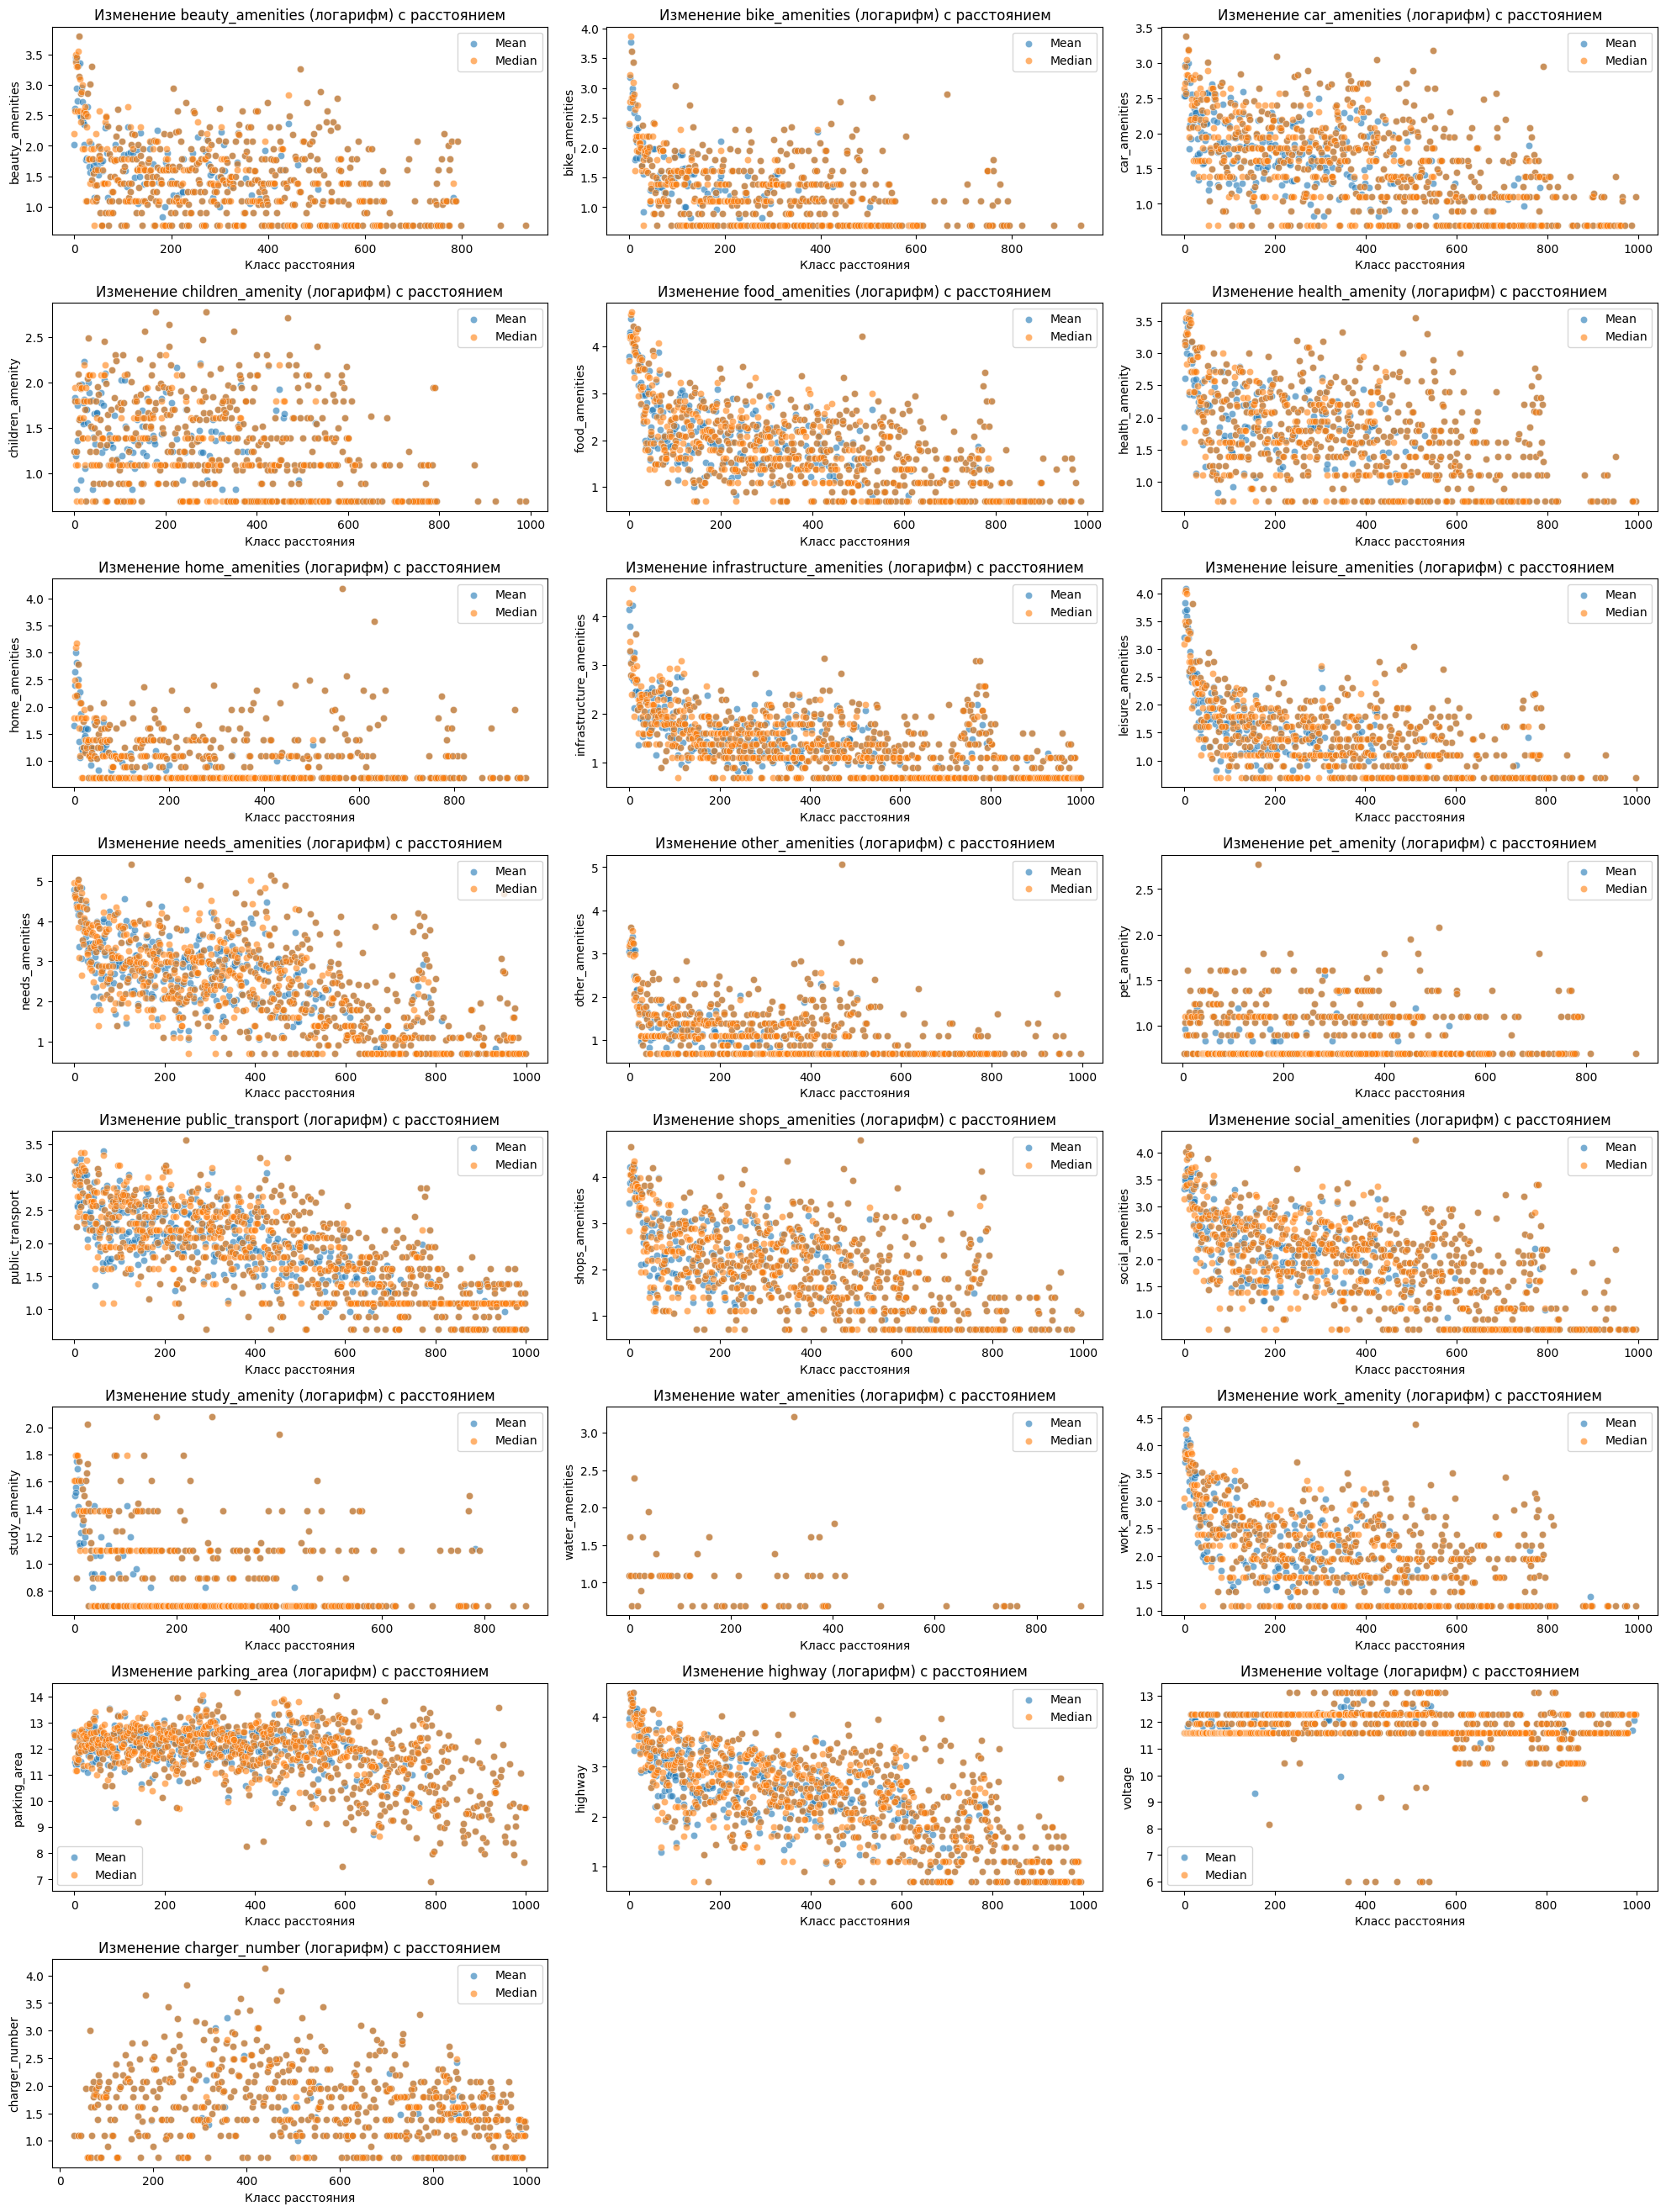

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 200))

for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(61, 3, i)
    
    data = aggregated_df_log[col]

    sns.scatterplot(x=aggregated_df_log.index, y=data["mean"], label="Mean", alpha=0.6)
    sns.scatterplot(x=aggregated_df_log.index, y=data["median"], label="Median", alpha=0.6)

    plt.title(f"Изменение {col} (логарифм) с расстоянием")
    plt.xlabel("Класс расстояния")
    plt.ylabel(col)
    plt.legend()

plt.tight_layout()
plt.show()